# Example: assessing operation of a fixed design

In [14]:
import calliope
import pandas as pd
from plotting_utilities import plot_dispatch, plot_capacity

calliope.set_log_verbosity('INFO', include_solver_output=False) # Defines how much information you get from the machine as the model gets built and run

## 1. Loading a previously-obtained system design

In [15]:
# Load the model(s) from a previously-run case (see the 'example_design_optimisation' notebook)
model = calliope.read_netcdf('results/cost-optimal-design.nc')
nuts2_model = calliope.read_netcdf('results/cost-optimal-design_nuts2.nc')

[2026-02-26 16:58:11] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:58:11] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:58:11] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:58:12] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:58:12] INFO     Model: initialisation complete
[2026-02-26 16:58:12] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:58:12] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:58:12] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:58:13] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:58:13] INFO     Model: initialisation complete


## 2. Creating override to re-run the same design for any operating conditions

In [16]:
from convert_plan_to_fixed_design import plan_results_to_fixedcap_override

In [17]:
plan_results_to_fixedcap_override(model, filename="cost-optimal")
plan_results_to_fixedcap_override(nuts2_model, filename="cost-optimal-nuts2")

In [18]:
# Re-run the model(s) with fixed capacities and SAME OPERATING CONDITIONS
# and check that the results are the same as the ones loaded initially
model_fixed_design = calliope.read_yaml(
    'model_files/model.yaml', 
    scenario='fix-design-to-cost-optimal'
)
nuts2_model_fixed_design = calliope.read_yaml(
    'model_files/nuts2_model.yaml', 
    scenario='fix-design-to-cost-optimal-nuts2'
)

[2026-02-26 16:58:21] INFO     (scenarios, fix-design-to-cost-optimal ) | Applying the following overrides: ['fix-design-to-cost-optimal'].
[2026-02-26 16:58:21] INFO     Math init | loading pre-defined math.
[2026-02-26 16:58:21] INFO     Math init | loading math files {'storage_inter_cluster', 'spores', 'milp', 'additional_math', 'base', 'operate'}.
[2026-02-26 16:58:22] INFO     Model: preprocessing data
[2026-02-26 16:58:22] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:58:30] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:58:30] INFO     Model: initialisation complete
[2026-02-26 16:58:30] INFO     (scenarios, fix-design-to-cost-optimal-nuts2 ) | Applying the following overrides: ['fix-design-to-cost-optimal-nuts2'].
[2026-02-26 16:58:30] INFO     Math init | loading pre-defined math.
[2026-02-26 16:58:30] INFO     Math init | loading math files {'storage_int

In [19]:
model_fixed_design.build()
model_fixed_design.solve()

[2026-02-26 16:58:41] INFO     Model: backend build starting
[2026-02-26 16:58:42] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 16:58:42] INFO     Optimisation Model | variables | Generated.
[2026-02-26 16:58:46] INFO     Optimisation Model | global_expressions | Generated.
[2026-02-26 16:58:55] INFO     Optimisation Model | constraints | Generated.
[2026-02-26 16:58:55] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-02-26 16:58:55] INFO     Optimisation Model | objectives | Generated.
[2026-02-26 16:58:55] INFO     Model: backend build complete
[2026-02-26 16:59:02] INFO     Optimisation model | starting model in base mode.
ERROR: No solution is available
[2026-02-26 16:59:09] CRITICAL Problem status:
[2026-02-26 16:59:09] CRITICAL 
[2026-02-26 16:59:09] CRITICAL Name: x1
[2026-02-26 16:59:09] CRITICAL Lower bound: -.inf
[2026-02-26 16:59:09] CRITICAL Upper bound: .inf
[2026-02-26 16:59:09] CRITICAL Number of objectives: 1
[2026-02-

In [20]:
nuts2_model_fixed_design.build()
nuts2_model_fixed_design.solve()

[2026-02-26 16:59:13] INFO     Model: backend build starting
[2026-02-26 16:59:14] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 16:59:15] INFO     Optimisation Model | variables | Generated.
[2026-02-26 16:59:17] INFO     Optimisation Model | global_expressions | Generated.
[2026-02-26 16:59:23] INFO     Optimisation Model | constraints | Generated.
[2026-02-26 16:59:23] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-02-26 16:59:23] INFO     Optimisation Model | objectives | Generated.
[2026-02-26 16:59:23] INFO     Model: backend build complete
[2026-02-26 16:59:27] INFO     Optimisation model | starting model in base mode.
[2026-02-26 16:59:35] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:07.460396
[2026-02-26 16:59:35] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 16:59:35] INFO     Postprocessing: ended. Time since start of solving optimisa

### Check that the 'fixed-design' results (largely) overlap with those obtained in plan mode

In [21]:
# Percentage error in the objective function value
print(
      """
      The percentage error is {}%
      """.format(round(100 * (model.results.cost.sum().values - model_fixed_design.results.cost.sum().values) 
                 / model.results.cost.sum().values, 3) )
)

AttributeError: 'Dataset' object has no attribute 'cost'

In [22]:
# Percentage error in the objective function value (NUTS 2)
print(
      """
      The percentage error is {}%
      """.format(round(100 * (nuts2_model.results.cost.sum().values - nuts2_model_fixed_design.results.cost.sum().values) 
                 / nuts2_model.results.cost.sum().values, 3) )
)


      The percentage error is -0.006%
      


## 3. Testing alternative operating conditions

This test is showcased for the NUTS2 model version only. The same logic applies to the highly-resolved model version.
We apply an on-the-fly override dictionary to make the cost of imported electricity 10 times cheaper.

In [23]:
nuts2_model_fixed_design_cheapimport = calliope.read_yaml(
    'model_files/nuts2_model.yaml', scenario='fix-design-to-cost-optimal-nuts2',
    override_dict={'techs.import_power.cost_flow_out.data': 0.01}
)

[2026-02-26 16:59:56] INFO     (scenarios, fix-design-to-cost-optimal-nuts2 ) | Applying the following overrides: ['fix-design-to-cost-optimal-nuts2'].
[2026-02-26 16:59:56] INFO     Math init | loading pre-defined math.
[2026-02-26 16:59:56] INFO     Math init | loading math files {'storage_inter_cluster', 'spores', 'milp', 'additional_math', 'base', 'operate'}.
[2026-02-26 16:59:56] INFO     Model: preprocessing data
[2026-02-26 16:59:56] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 17:00:00] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:00:00] INFO     Model: initialisation complete


In [24]:
nuts2_model_fixed_design_cheapimport.build()
nuts2_model_fixed_design_cheapimport.solve()

[2026-02-26 17:00:00] INFO     Model: backend build starting
[2026-02-26 17:00:02] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 17:00:02] INFO     Optimisation Model | variables | Generated.
[2026-02-26 17:00:04] INFO     Optimisation Model | global_expressions | Generated.
[2026-02-26 17:00:10] INFO     Optimisation Model | constraints | Generated.
[2026-02-26 17:00:10] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-02-26 17:00:10] INFO     Optimisation Model | objectives | Generated.
[2026-02-26 17:00:10] INFO     Model: backend build complete
[2026-02-26 17:00:14] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:00:21] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:07.557600
[2026-02-26 17:00:21] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 17:00:21] INFO     Postprocessing: ended. Time since start of solving optimisa

In [25]:
nuts2_model_fixed_design_cheapimport.to_netcdf('results/fixed-cost-optimal-design_nuts2_cheapimport.nc')

In [28]:
# First, let's load consistent colours and names for our technologies
df = pd.read_csv('model_files/techs_and_nodes/tech_names_and_colours.csv')
colours = dict(zip(df['technology_id'], df['color']))

[2026-02-26 17:01:15] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:01:15] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 17:01:15] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:01:15] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:01:15] INFO     Model: initialisation complete


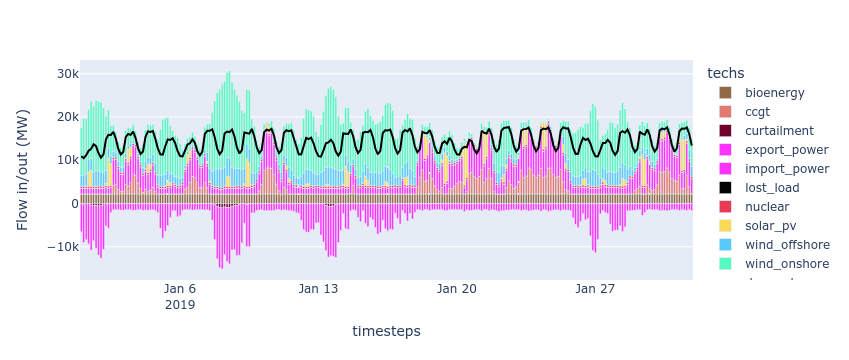

In [29]:
# Inspect the difference from the initial operation visually
plot_dispatch('results/fixed-cost-optimal-design_nuts2_cheapimport.nc', exclude_transmission=True, colors=colours)